In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [5]:
data = pd.DataFrame({

    "Study_Hours":       [1, 2, 3, 4, 5, 6, 7, 8],

    "Practice_Tests":    [0, 1, 1, 2, 2, 3, 3, 4],

    "Attendance":        [60, 65, 70, 75, 80, 85, 90, 95],

    "Assignments":       [1, 1, 2, 2, 3, 3, 4, 4],
"Phone_Hours":       [8, 7, 9, 8, 10, 9, 11, 10],

    "Social_Media":      [6, 7, 5, 8, 7, 6, 9, 8],

    "Favourite_Number":  [3, 7, 2, 9, 4, 6, 1, 8],

    "Bus_Route":         [2, 1, 3, 2, 4, 1, 3, 2],

    "Pass":              [0, 0, 0, 1, 1, 1, 1, 1]
})

display(data)

,Study_Hours,Practice_Tests,Attendance,Assignments,Phone_Hours,Social_Media,Favourite_Number,Bus_Route,Pass
0,1,0,60,1,8,6,3,2,0
1,2,1,65,1,7,7,7,1,0
2,3,1,70,2,9,5,2,3,0
3,4,2,75,2,8,8,9,2,1
4,5,2,80,3,10,7,4,4,1
5,6,3,85,3,9,6,6,1,1
6,7,3,90,4,11,9,1,3,1
7,8,4,95,4,10,8,8,2,1


In [6]:
X = data.drop(columns=["Pass"])
y = data["Pass"]

print("\nNumber of students :", len(data))
print("Number of variables:", X.shape[1])


Number of students : 8
Number of variables: 8


In [7]:
print("Using simple Logistic Regression- Taking all 8 variables")
model_all = make_pipeline(
    StandardScaler(),
    LogisticRegression(penalty=None, max_iter=1000)
)

model_all.fit(X, y)

Using simple Logistic Regression- Taking all 8 variables


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(max_iter=1000, penalty=None))])

In [8]:
print("Do Lasso regression- Unwanted variables out of 8 will get penalty and will be removed.")
lasso = make_pipeline(
    StandardScaler(),
    Lasso(alpha=0.15)
)
lasso.fit(X, y)

lasso_model = lasso.named_steps["lasso"]

print("\nLASSO COEFFICIENTS")
print("-" * 70)

for variable, coefficient in zip(
    X.columns,
    lasso_model.coef_
):

    if abs(coefficient) < 0.001:
        print(
            f"✗ {variable:20s} -> "
            f"{coefficient:8.3f} -> REMOVED"
        )

    else:

        print(
            f"{variable:20s} -> "
            f"{coefficient:8.3f} -> RETAINED"
        )



Do Lasso regression- Unwanted variables out of 8 will get penalty and will be removed.

LASSO COEFFICIENTS
----------------------------------------------------------------------
Study_Hours          ->    0.152 -> RETAINED
Practice_Tests       ->    0.105 -> RETAINED
✗ Attendance           ->    0.000 -> REMOVED
✗ Assignments          ->    0.000 -> REMOVED
✗ Phone_Hours          ->    0.000 -> REMOVED
Social_Media         ->    0.007 -> RETAINED
✗ Favourite_Number     ->    0.000 -> REMOVED
✗ Bus_Route            ->    0.000 -> REMOVED


In [9]:
print("Ridge regression, Keeps all the variables, reduces coefficient values towards 0")
ridge = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0)
)

ridge.fit(X, y)

ridge_model = ridge.named_steps["ridge"]

print("\nRIDGE COEFFICIENTS")
print("-" * 70)

for variable, coefficient in zip(
    X.columns,
    ridge_model.coef_
):

    print(
        f"{variable:20s} -> {coefficient:8.3f}"
    )


Ridge regression, Keeps all the variables, reduces coefficient values towards 0

RIDGE COEFFICIENTS
----------------------------------------------------------------------
Study_Hours          ->    0.074
Practice_Tests       ->    0.074
Attendance           ->    0.074
Assignments          ->    0.070
Phone_Hours          ->    0.052
Social_Media         ->    0.070
Favourite_Number     ->    0.136
Bus_Route            ->    0.075


In [10]:
print("CROSS-VALIDATION — WHICH MODEL SHOULD WE TRUST?")
cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

models = {

    "All Variables":
        make_pipeline(
            StandardScaler(),
            LogisticRegression(
                penalty=None,
                max_iter=1000
            )
        ),

    "L1 Regularization": #
        make_pipeline(
            StandardScaler(),
            LogisticRegression(
                penalty="l1",
                solver="liblinear"
            )
        ),

    "L2 Regularization":
        make_pipeline(
            StandardScaler(),
            LogisticRegression(
                penalty="l2",
                max_iter=1000
            )
        )
}

print("\nCROSS-VALIDATION RESULTS")
print("-" * 70)

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    print(
        f"{name:25s} -> "
        f"Average Accuracy = {scores.mean():.2f}"
    )


CROSS-VALIDATION — WHICH MODEL SHOULD WE TRUST?

CROSS-VALIDATION RESULTS
----------------------------------------------------------------------
All Variables             -> Average Accuracy = 0.75
L1 Regularization         -> Average Accuracy = 0.75


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=4.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=4.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=4.
  warnings.warn(


L2 Regularization         -> Average Accuracy = 0.88



Creating Lasso visualization...


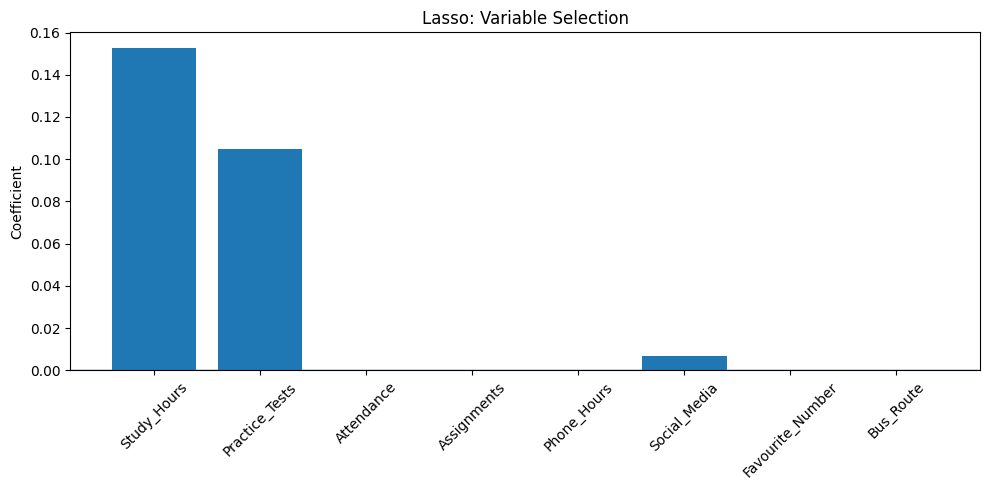

In [15]:
print("\nCreating Lasso visualization...")

plt.figure(figsize=(10, 5))

plt.bar(
    X.columns,
    lasso_model.coef_)

plt.axhline(
    0,
    linewidth=1
)

plt.title("Lasso: Variable Selection")
plt.ylabel("Coefficient")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [16]:
#For the Big N
big_n_data = pd.DataFrame({

    "Study_Hours":
        [1, 2, 3, 4, 5, 6, 7, 8],

    "Performance":
        [42, 48, 53, 60, 67, 73, 81, 88]
})


In [17]:
X_simple = big_n_data[["Study_Hours"]]
y_simple = big_n_data["Performance"]

ols = LinearRegression() #Use the whole dataset

ols.fit(
    X_simple,
    y_simple
)

print("\n" + "=" * 70)
print("1. FULL-DATA OLS")
print("=" * 70)

print(f"Intercept = {ols.intercept_:.3f}")
print(f"Slope     = {ols.coef_[0]:.3f}")


1. FULL-DATA OLS
Intercept = 34.321
Slope     = 6.595


In [18]:
# First 4 observations = subsample
X_sub = X_simple.iloc[:4].values
y_sub = y_simple.iloc[:4].values

# Remaining observations
X_remaining = X_simple.iloc[4:].values
y_remaining = y_simple.iloc[4:].values

# Add intercept column
X_sub_matrix = np.column_stack([
    np.ones(len(X_sub)),
    X_sub.flatten()
])

X_remaining_matrix = np.column_stack([
    np.ones(len(X_remaining)),
    X_remaining.flatten()
])

# OLS on subsample
b_sub = np.linalg.inv(
    X_sub_matrix.T @ X_sub_matrix
) @ (
    X_sub_matrix.T @ y_sub
)
# Calculate residuals on remaining observations
residuals = (
    y_remaining -
    X_remaining_matrix @ b_sub
)

# Uluru correction
correction = (
    len(X_sub) / len(X_remaining)
) * np.linalg.inv(
    X_sub_matrix.T @ X_sub_matrix
) @ (
    X_remaining_matrix.T @ residuals
)

b_uluru = b_sub + correction

print("\nFULL OLS")
print("-" * 70)
print(
    f"Intercept = {ols.intercept_:.3f}"
)
print(
    f"Slope     = {ols.coef_[0]:.3f}"
)

print("\nSUBSAMPLE OLS")
print("-" * 70)
print(
    f"Intercept = {b_sub[0]:.3f}"
)
print(
    f"Slope     = {b_sub[1]:.3f}"
)

print("\nULURU ESTIMATE")
print("-" * 70)
print(
    f"Intercept = {b_uluru[0]:.3f}"
)
print(
    f"Slope     = {b_uluru[1]:.3f}"
)


FULL OLS
----------------------------------------------------------------------
Intercept = 34.321
Slope     = 6.595

SUBSAMPLE OLS
----------------------------------------------------------------------
Intercept = 36.000
Slope     = 5.900

ULURU ESTIMATE
----------------------------------------------------------------------
Intercept = 12.700
Slope     = 16.380


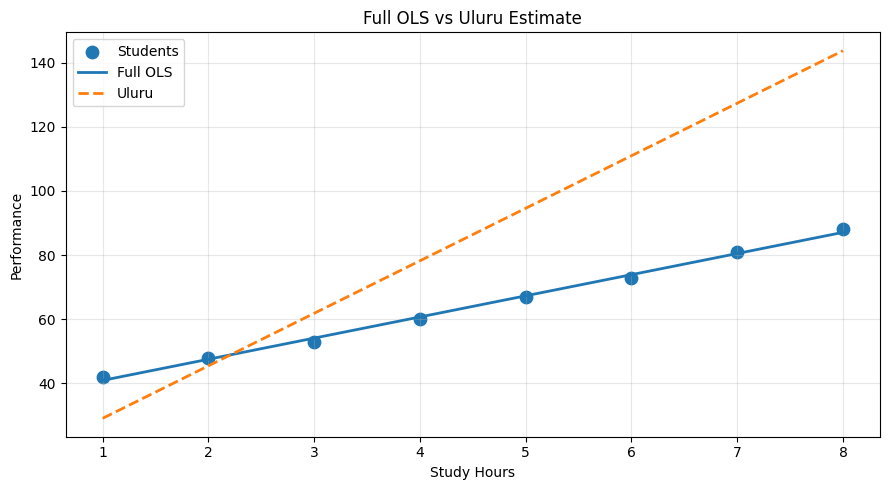

In [19]:
plt.figure(figsize=(9, 5))

plt.scatter(
    X_simple,
    y_simple,
    s=80,
    label="Students"
)

# Full OLS line
x_line = np.linspace(
    1,
    8,
    100
)

ols_line = (
    ols.intercept_ +
    ols.coef_[0] * x_line
)
uluru_line = (
    b_uluru[0] +
    b_uluru[1] * x_line
)

plt.plot(
    x_line,
    ols_line,
    linewidth=2,
    label="Full OLS"
)

plt.plot(
    x_line,
    uluru_line,
    linestyle="--",
    linewidth=2,
    label="Uluru"
)

plt.xlabel("Study Hours")
plt.ylabel("Performance")

plt.title("Full OLS vs Uluru Estimate")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
print("""
                    BIG DATA
                       |
             ---------------------
             |                   |
           BIG P               BIG N
             |                   |
      Many Variables       Many Observations
             |                   |
       "What should        "How can we
        I keep?"            calculate efficiently?"
             |                   |
     ----------------       --------------
     |              |       |            |
   LASSO           RIDGE    OLS         ULURU
     |
     |
Variable Selection

CROSS-VALIDATION
helps compare models using
unseen/validation data.

Remember:

BIG P -> Too many variables -> LASSO / regularization

BIG N -> Too many observations -> Computational methods
                                      such as Uluru
""")


                    BIG DATA
                       |
             ---------------------
             |                   |
           BIG P               BIG N
             |                   |
      Many Variables       Many Observations
             |                   |
       "What should        "How can we
        I keep?"            calculate efficiently?"
             |                   |
     ----------------       --------------
     |              |       |            |
   LASSO           RIDGE    OLS         ULURU
     |
     |
Variable Selection

CROSS-VALIDATION
helps compare models using
unseen/validation data.

Remember:

BIG P -> Too many variables -> LASSO / regularization

BIG N -> Too many observations -> Computational methods
                                      such as Uluru



In [21]:
#Understand logistic regression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

In [22]:
data = pd.DataFrame({

    "Study_Hours": [1, 2, 3, 4, 5], #X

    "Pass": [0, 0, 0, 1, 1] #Y
})
display(data)

,Study_Hours,Pass
0,1,0
1,2,0
2,3,0
3,4,1
4,5,1


In [23]:
X = data["Study_Hours"].values
y = data["Pass"].values

In [25]:
model = LogisticRegression(
    penalty=None,
    solver="lbfgs"
)

model.fit(
    X.reshape(-1, 1),
    y
)

b0 = model.intercept_[0]
b1 = model.coef_[0][0]
print(
    f"Intercept b0  = {b0:.4f}"
)

print(
    f"Coefficient b1 = {b1:.4f}"
)

Intercept b0  = -61.5897
Coefficient b1 = 17.5539


In [26]:
print(
    f"\nz = {b0:.4f} + "
    f"({b1:.4f} × Study_Hours)"
)


z = -61.5897 + (17.5539 × Study_Hours)


In [34]:
new_student_hours = 1
print( f"\nThe new student studied "f"{new_student_hours} hours.")
z = (
    b0 +
    b1 * new_student_hours
)

print("\nFirst calculate z:")

print(
    f"z = {b0:.4f} + "
    f"({b1:.4f} × {new_student_hours})"
)

print(
    f"z = {z:.4f}"
)


The new student studied 1 hours.

First calculate z:
z = -61.5897 + (17.5539 × 1)
z = -44.0358


In [38]:
def sigmoid(z):
  return 1/(1+np.exp(-z))

probability = sigmoid(z)

print("\nNow calculate probability:")

print(
    "P = 1 / (1 + e^(-z))"
)

print(
    f"P = 1 / (1 + e^(-{z:.4f}))"
)

print(
    f"P = {probability:.4f}"
)

print(
    f"\nProbability of PASS = "
    f"{probability * 100:.2f}%"
)


Now calculate probability:
P = 1 / (1 + e^(-z))
P = 1 / (1 + e^(--44.0358))
P = 0.0000

Probability of PASS = 0.00%


In [39]:
prediction = (
    1
    if probability >= 0.50
    else 0
)

print("\n" + "=" * 70)
print("STEP 6 — FINAL DECISION")
print("=" * 70)

print(
    f"Probability = "
    f"{probability * 100:.2f}%"
)

print(
    "Decision threshold = 50%"
)

if prediction == 1:

    print(
        "\nFINAL PREDICTION: PASS"
    )
else:

    print(
        "\nFINAL PREDICTION: FAIL"
    )


STEP 6 — FINAL DECISION
Probability = 0.00%
Decision threshold = 50%

FINAL PREDICTION: FAIL
